In [3]:
#LIBRERIAS
import io
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import cm
from astropy.io import fits
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from astropy.stats import sigma_clip
from matplotlib.patches import Circle
from photutils.utils import calc_total_error
from IPython.display import Image as IPyImage, display
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from astropy.visualization import ZScaleInterval, ImageNormalize, LinearStretch, LogStretch
from scipy.ndimage import gaussian_filter
from photutils.aperture import ApertureStats



import warnings
# Ignorar todos los warnings
warnings.filterwarnings("ignore")

In [27]:
folder_path = r"C:/Users/HP/Desktop/Maestria/TESIS/20241009_66146"
search_radius = 10

# -----------------------------
# Entrada de coordenadas y tracking
# -----------------------------
print("\n=== COORDENADAS INICIALES (para validación de GIF) ===")

x_astro = float(input("Asteroide - x: "))
y_astro = float(input("Asteroide - y: "))
initial_asteroid_coords = (x_astro, y_astro)

n_star = int(input("Número de estrellas de referencia: "))
initial_ref_stars = []
for i in range(n_star):
    print(f"\nEstrella de referencia {i+1}:")
    x_ref = float(input(f"x{i+1}: "))
    y_ref = float(input(f"y{i+1}: "))
    initial_ref_stars.append((x_ref, y_ref))

print("\n=== RESUMEN DE COORDENADAS ===")
print(f"Asteroide: x={initial_asteroid_coords[0]}, y={initial_asteroid_coords[1]}")
for i, (x, y) in enumerate(initial_ref_stars, start=1):
    print(f"Estrella {i}: x={x}, y={y}")

# Corrección opcional antes del GIF
while True:
    corregir = input("\n¿Deseas corregir alguna coordenada? (s/n): ").strip().lower()
    if corregir == "n":
        break
    elif corregir == "s":
        tipo = input("¿Qué deseas corregir? (a = asteroide, e = estrella): ").strip().lower()
        if tipo == "a":
            x_astro = float(input("Nuevo valor x del asteroide: "))
            y_astro = float(input("Nuevo valor y del asteroide: "))
            initial_asteroid_coords = (x_astro, y_astro)
            print("✅ Coordenadas del asteroide actualizadas.")
        elif tipo == "e":
            idx = int(input(f"¿Qué estrella deseas corregir? (1-{n_star}): ")) - 1
            x_ref = float(input("Nuevo valor x: "))
            y_ref = float(input("Nuevo valor y: "))
            initial_ref_stars[idx] = (x_ref, y_ref)
            print(f"✅ Coordenadas de la estrella {idx+1} actualizadas.")
        else:
            print("⚠️ Opción no válida. Intenta de nuevo.")
        print("\n=== COORDENADAS ACTUALIZADAS ===")
        print(f"Asteroide: x={initial_asteroid_coords[0]}, y={initial_asteroid_coords[1]}")
        for i, (x, y) in enumerate(initial_ref_stars, start=1):
            print(f"Estrella {i}: x={x}, y={y}")
    else:
        print("⚠️ Responde solo con 's' o 'n'.")


=== COORDENADAS INICIALES (para validación de GIF) ===


Asteroide - x:  424.354
Asteroide - y:  521.055
Número de estrellas de referencia:  3



Estrella de referencia 1:


x1:  722.389
y1:  533.138



Estrella de referencia 2:


x2:  831.132
y2:  71.9882



Estrella de referencia 3:


x3:  482.752
y3:  958.039



=== RESUMEN DE COORDENADAS ===
Asteroide: x=424.354, y=521.055
Estrella 1: x=722.389, y=533.138
Estrella 2: x=831.132, y=71.9882
Estrella 3: x=482.752, y=958.039



¿Deseas corregir alguna coordenada? (s/n):  n


In [ ]:
print("\n🔍 Calculando RADIO_APERTURA óptimo...")
fits_files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith("o2.fits")])
print(f"\nSe encontraron {len(fits_files)} imágenes FITS (terminadas en 'o2.fits').")
with fits.open(fits_files[0]) as hdul:
    data = hdul[0].data.astype(float)
# -----------------------------
# Tracking simple
# -----------------------------
def track_position(data, x_prev, y_prev, search_radius=10):
    x_prev, y_prev = int(round(x_prev)), int(round(y_prev))
    y_min = max(0, y_prev - search_radius)
    y_max = min(data.shape[0], y_prev + search_radius + 1)
    x_min = max(0, x_prev - search_radius)
    x_max = min(data.shape[1], x_prev + search_radius + 1)

    sub_img = data[y_min:y_max, x_min:x_max].copy()

    # Coordenadas dentro de la subimagen
    yy, xx = np.mgrid[:sub_img.shape[0], :sub_img.shape[1]]
    
    # Centro esperado (posición anterior dentro de la subimagen)
    xc = x_prev - x_min
    yc = y_prev - y_min
    
    # Máscara circular
    r = np.sqrt((xx - xc)**2 + (yy - yc)**2)
    mask = r <= RADIO_APERTURA      # o 1.2*RADIO_APERTURA
    
    # Ignorar todo lo que esté fuera del círculo
    sub_img[~mask] = -np.inf
    
    # Copia para suavizar
    sub_smooth = sub_img.copy()
    
    # Reemplazar -inf para que el filtro no falle
    sub_smooth[np.isneginf(sub_smooth)] = np.nanmedian(sub_smooth[np.isfinite(sub_smooth)])
    
    # Suavizar
    sub_smooth = gaussian_filter(sub_smooth, sigma=1.2)
    
    # Buscar máximo
    y_peak, x_peak = np.unravel_index(np.argmax(sub_smooth), sub_smooth.shape)
    
    return x_min + x_peak, y_min + y_peak

# -----------------------------
# FUNCIÓN: Calcular radio óptimo del asteroide
# -----------------------------

def calcular_fwhm_optimo(data, x, y, search_radius=15):
    print(f"\n📏 Analizando perfil de luz en x={x:.1f}, y={y:.1f}...")
    
    # Centro entero aproximado
    x_c, y_c = int(round(x)), int(round(y))

    # Subimagen alrededor del objeto
    sub = data[
        max(0, y_c - search_radius):min(data.shape[0], y_c + search_radius + 1),
        max(0, x_c - search_radius):min(data.shape[1], x_c + search_radius + 1)
    ]

    if sub.size == 0:
        print("⚠️ Error: Sub-imagen vacía (borde de imagen).")
        return 4.0

    # Centro exacto de luz (máximo)
    y0, x0 = np.unravel_index(np.argmax(sub), sub.shape)

    # Coordenadas radiales
    yy, xx = np.mgrid[:sub.shape[0], :sub.shape[1]]
    r = np.sqrt((yy - y0)**2 + (xx - x0)**2)

    # Perfil radial
    radios = np.arange(0, 12, 0.5)
    profile = []

    for rad in radios:
        mask = (r >= rad - 0.25) & (r < rad + 0.25)
        if np.any(mask):
            profile.append(np.mean(sub[mask]))
        else:
            profile.append(np.nan)

    profile = np.array(profile)

    # --- RESTA DE FONDO ---
    fondo = np.nanmedian(profile[-5:])
    profile_corr = profile - fondo
    profile_corr[profile_corr < 0] = 0

    peak = np.nanmax(profile_corr)

    if peak <= 0:
        print("⚠️ Objeto demasiado débil para medir FWHM.")
        return 4.0

    # --- CÁLCULO CORRECTO DEL FWHM ---
    half_max = peak / 2.0
    idx = np.where(profile_corr <= half_max)[0]

    if len(idx) > 0:
        r_half = radios[idx[0]]
        fwhm_px = 2.0 * r_half
    else:
        fwhm_px = 3.0
        print("⚠️ No se encontró cruce de half-max. Usando FWHM por defecto.")

    print(f"   🔹 FWHM detectado: {fwhm_px:.2f} píxeles")

    # --- RADIO DE APERTURA ÓPTIMO (asteroides) ---
    radio_optimo = max(2.2 * fwhm_px, 4.0)

    print(f"   🎯 Radio de Apertura recomendado: {radio_optimo:.2f} píxeles")

    return radio_optimo


# ==========================================
# RADIO_APERTURA con confirmación explícita de noche
# ==========================================

print("\n🌙 Control del RADIO DE APERTURA")

# ¿Existe un radio previo?
if 'RADIO_APERTURA_PREVIO' in globals():
    print(f"📌 Radio almacenado: {RADIO_APERTURA_PREVIO:.2f} px")
    resp = input("¿Es la MISMA noche de observación? [S/n]: ").strip().lower()

    # Enter o SÍ → conservar
    if resp == "" or resp in ["s", "si", "y", "yes"]:
        RADIO_APERTURA = RADIO_APERTURA_PREVIO
        print(f"✅ Radio CONSERVADO: {RADIO_APERTURA:.2f} px")

    # NO → recalcular
    else:
        print("🔄 Nueva noche → recalculando radio...")
        RADIO_APERTURA = calcular_fwhm_optimo(data, x_astro, y_astro)
        RADIO_APERTURA_PREVIO = RADIO_APERTURA
        print(f"💾 Nuevo radio guardado: {RADIO_APERTURA:.2f} px")

# Primera vez: no hay radio previo
else:
    print("🆕 Primera ejecución: calculando radio inicial...")
    RADIO_APERTURA = calcular_fwhm_optimo(data, x_astro, y_astro)
    RADIO_APERTURA_PREVIO = RADIO_APERTURA
    print(f"💾 Radio inicial guardado: {RADIO_APERTURA:.2f} px")

# Factores del anillo de cielo
inner_sky_radius_factor = 2.5
outer_sky_radius_factor = 4.0

print(f"\n📊 FINAL: RADIO_APERTURA = {RADIO_APERTURA:.2f} px")


def generar_gif_seguimiento(fits_files, asteroid_traj, ref_trajs, aperture_radius, 
                           inner_sky_factor=2.5, outer_sky_factor=4.0, 
                           output_gif="seguimiento_asteroide.gif"):
    """Genera GIF mostrando aperturas fotométricas del asteroide y estrellas de referencia."""
    print("\n=== Generando GIF con aperturas fotométricas ===")
    
    frames = []
    n_images = len(fits_files)
    n_refs = len(ref_trajs)
    
    # Colores
    color_asteroid = "#00FF00"
    ref_colors = cm.get_cmap('tab10')(np.arange(n_refs))
    
    # Inicializamos el calculador de intervalos ZScale
    interval = ZScaleInterval()
    
    for i, fits_file in enumerate(tqdm(fits_files, desc="Creando cuadros")):
        with fits.open(fits_file) as hdul:
            data = hdul[0].data.astype(float)
        
        # AJUSTE DE CONTRASTE
        vmin, vmax = interval.get_limits(data)
        norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=LinearStretch())
        
        fig, ax = plt.subplots(figsize=(6, 6))
        
        # Imagen con normalización ZScale
        im = ax.imshow(data, origin="lower", cmap="gray", norm=norm)
        
        # Asteroide
        x_ast, y_ast = asteroid_traj[i]
        aper_ast = Circle((x_ast, y_ast), aperture_radius,
                         edgecolor=color_asteroid, facecolor="none", lw=1.5)
        sky_in_ast = Circle((x_ast, y_ast), aperture_radius * inner_sky_factor,
                           edgecolor=color_asteroid, facecolor="none", lw=0.8, ls="--")
        sky_out_ast = Circle((x_ast, y_ast), aperture_radius * outer_sky_factor,
                            edgecolor=color_asteroid, facecolor="none", lw=0.8, ls="--")
        ax.add_patch(aper_ast)
        ax.add_patch(sky_in_ast)
        ax.add_patch(sky_out_ast)
        ax.text(x_ast + 5, y_ast + 5, "Asteroide", 
                color=color_asteroid, fontsize=10, weight="bold")
        
        # Estrellas de referencia
        for j in range(n_refs):
            x_ref, y_ref = ref_trajs[j][i]
            c = ref_colors[j]
            
            aper_ref = Circle((x_ref, y_ref), aperture_radius,
                             edgecolor=c, facecolor="none", lw=1.2)
            sky_in_ref = Circle((x_ref, y_ref), aperture_radius * inner_sky_factor,
                               edgecolor=c, facecolor="none", lw=0.7, ls="--")
            sky_out_ref = Circle((x_ref, y_ref), aperture_radius * outer_sky_factor,
                                edgecolor=c, facecolor="none", lw=0.7, ls="--")
            ax.add_patch(aper_ref)
            ax.add_patch(sky_in_ref)
            ax.add_patch(sky_out_ref)
            
            ax.text(x_ref + 5, y_ref + 5, f"Ref {j+1}",
                    color=c, fontsize=9, weight="bold")
        
        ax.set_title(f"Imagen {i+1}/{n_images}")
        ax.set_xlabel("x [px]")
        ax.set_ylabel("y [px]")
        plt.tight_layout()
        
        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        frame = PILImage.open(buf)
        frames.append(frame)
    
    frames[0].save(output_gif, save_all=True, append_images=frames[1:],
                  duration=150, loop=0)
    print(f"✅ GIF guardado: {output_gif}")
    display(IPyImage(filename=output_gif))
    


# EJECUCIÓN DEL TRACKING Y GIF
print("🔍 Tracking trayectorias para GIF...")
asteroid_coords = []
ref_stars_coords = []

for i, fits_file in enumerate(tqdm(fits_files, desc="Tracking para GIF")):
    with fits.open(fits_file) as hdul:
        data = hdul[0].data.astype(float)
    
    # Asteroide
    x_prev, y_prev = asteroid_coords[-1] if i > 0 else initial_asteroid_coords
    x_astro, y_astro = track_position(data, x_prev, y_prev, search_radius)
    asteroid_coords.append((x_astro, y_astro))
    
    # Estrellas referencia
    current_ref_coords = []
    for j, ref_init in enumerate(initial_ref_stars):
        x_prev, y_prev = ref_stars_coords[-1][j] if i > 0 else ref_init
        x_ref, y_ref = track_position(data, x_prev, y_prev, search_radius)
        current_ref_coords.append((x_ref, y_ref))
    ref_stars_coords.append(current_ref_coords)

# Construir trayectorias por estrella
n_images = len(asteroid_coords)
n_refs = len(initial_ref_stars)
ref_trajs = [[ref_stars_coords[i][j] for i in range(n_images)] for j in range(n_refs)]

# Generar GIF
gif_name = "seguimiento_asteroide_refs.gif"
gif_path = os.path.join(folder_path, gif_name)

generar_gif_seguimiento(
    fits_files=fits_files,
    asteroid_traj=asteroid_coords,
    ref_trajs=ref_trajs,
    aperture_radius=RADIO_APERTURA,
    inner_sky_factor=inner_sky_radius_factor,
    outer_sky_factor=outer_sky_radius_factor,
    output_gif=gif_name
)

print(f"\n📊 RADIO_APERTURA final: {RADIO_APERTURA:.1f} px")
print("   → Listo para usar en fotometría!")
print("\n🎬 Revisa el GIF 'seguimiento_asteroide_refs.gif'")
print("Si el tracking está correcto, ejecuta la celda de fotometría.")


🔍 Calculando RADIO_APERTURA óptimo...

Se encontraron 99 imágenes FITS (terminadas en 'o2.fits').

🌙 Control del RADIO DE APERTURA
📌 Radio almacenado: 6.00 px


¿Es la MISMA noche de observación? [S/n]:  n


🔄 Nueva noche → recalculando radio...

📏 Analizando perfil de luz en x=29.0, y=481.0...
   🔹 FWHM detectado: 2.00 píxeles
   🎯 Radio de Apertura recomendado: 4.40 píxeles
💾 Nuevo radio guardado: 4.40 px

📊 FINAL: RADIO_APERTURA = 4.40 px
🔍 Tracking trayectorias para GIF...


Tracking para GIF: 100%|██████████| 99/99 [00:00<00:00, 122.84it/s]



=== Generando GIF con aperturas fotométricas ===


Creando cuadros:  75%|███████▍  | 74/99 [00:57<00:15,  1.66it/s]

In [9]:
# ==========================
# Parámetros CCD 
# ==========================
GAIN = 2.2
READNOISE = 6.1

def get_detector_parameters(header):
    return float(GAIN), float(READNOISE)


def calc_total_error(data, readnoise, gain):
    data_safe = np.maximum(data, 0)
    return np.sqrt(data_safe / gain + (readnoise / gain)**2)


def calculate_flux_error(data, header, x, y, obj_radius,
                         inner_factor=3.0,
                         outer_factor=5.0):

    aperture = CircularAperture((x, y), r=obj_radius)

    annulus = CircularAnnulus(
        (x, y),
        r_in=obj_radius * inner_factor,
        r_out=obj_radius * outer_factor
    )

    gain, readnoise = get_detector_parameters(header)

    # Error CCD
    error = calc_total_error(data, readnoise, gain)

    # Flujo dentro de la apertura
    phot = aperture_photometry(data, aperture, error=error)

    flux_obj = phot['aperture_sum'][0]
    flux_obj_err = phot['aperture_sum_err'][0]

    # ---------- FONDO ROBUSTO ----------
    mask = annulus.to_mask(method='center')

    annulus_data = mask.multiply(data)
    
    annulus_pixels = annulus_data[mask.data > 0]
    
    annulus_pixels = annulus_pixels[np.isfinite(annulus_pixels)]
    
    annulus_pixels = sigma_clip(
        annulus_pixels,
        sigma=3,
        maxiters=5
    )
    
    sky = np.nanmedian(annulus_pixels)
    
    sky_std = np.nanstd(annulus_pixels)
    
    flux_final = flux_obj - sky * aperture.area
    
    flux_final_err = np.sqrt(
        flux_obj_err**2 +
        aperture.area * sky_std**2
    )
    return flux_final, flux_final_err

def calculate_magnitude(flux):

    if flux <= 0:
        return np.nan

    return -2.5*np.log10(flux)

def calculate_magnitude_error(flux, flux_error):

    if flux <= 0 or flux_error <= 0:
        return np.nan

    return (2.5 / np.log(10.0)) * (flux_error / flux)

# ==========================================
# 1) FOTOMETRÍA: flujos de asteroide y refs
# ==========================================
n_images = len(fits_files)
n_refs   = len(initial_ref_stars)

asteroid_fluxes     = np.zeros(n_images)
asteroid_flux_errs  = np.zeros(n_images)
ref_fluxes_all      = np.zeros((n_images, n_refs))
ref_flux_errs_all   = np.zeros((n_images, n_refs))
jd_times            = []

print("\n=== Iniciando fotometría (flujos en ADU) ===")

for i, fits_file in enumerate(tqdm(fits_files, desc="Fotometría")):
    with fits.open(fits_file) as hdul:
        data   = hdul[0].data.astype(float)
        header = hdul[0].header

    jd_times.append(header.get("JD", header.get("JD-OBS", np.nan)))

    # Asteroide
    x_astro, y_astro = asteroid_coords[i]
    flux_ast, flux_err_ast = calculate_flux_error(
        data, header, x_astro, y_astro,
        obj_radius=RADIO_APERTURA,
        inner_factor=inner_sky_radius_factor,
        outer_factor=outer_sky_radius_factor
    )
    asteroid_fluxes[i]    = flux_ast
    asteroid_flux_errs[i] = flux_err_ast

    # Estrellas de referencia
    for j, (x_ref, y_ref) in enumerate(ref_stars_coords[i]):
        flux_ref, flux_err_ref = calculate_flux_error(
            data, header, x_ref, y_ref,
            obj_radius=RADIO_APERTURA,
            inner_factor=inner_sky_radius_factor,
            outer_factor=outer_sky_radius_factor
        )
        ref_fluxes_all[i, j]    = flux_ref
        ref_flux_errs_all[i, j] = flux_err_ref

bad = asteroid_fluxes <= 0

print(f"Se descartarán {np.sum(bad)} imágenes con flujo negativo.")

asteroid_fluxes[bad] = np.nan
asteroid_flux_errs[bad] = np.nan

# ==========================================
# 2) MAGNITUDES INSTRUMENTALES
# ==========================================
m_astro = np.array([calculate_magnitude(F) for F in asteroid_fluxes])
dm_astro = np.array([calculate_magnitude_error(F, dF)
                     for F, dF in zip(asteroid_fluxes, asteroid_flux_errs)])

m_refs  = np.zeros_like(ref_fluxes_all)
dm_refs = np.zeros_like(ref_fluxes_all)
for j in range(n_refs):
    for i in range(n_images):
        m_refs[i, j]  = calculate_magnitude(ref_fluxes_all[i, j])
        dm_refs[i, j] = calculate_magnitude_error(ref_fluxes_all[i, j],
                                                  ref_flux_errs_all[i, j])

t   = np.array(jd_times, dtype=float)
t0  = t[0]
t_rel = t - t0

# ==========================================
# 3) SELECCIÓN AUTOMÁTICA DE REFERENCIAS
# ==========================================
SATURATION_LIMIT  = 57816.0   # ADU/píxel
SAT_FRAC          = 0.9
SAT_SEARCH_RADIUS = 5

print("\n=== Seleccionando referencias buenas (brillo, estabilidad, flujo, no saturación) ===")

# --- Brillo similar al asteroide ---
mean_m_astro = np.nanmean(m_astro)
mean_m_ref   = np.nanmean(m_refs, axis=0)

MAG_TOL = 1.5
mask_brillo = np.abs(mean_m_ref - mean_m_astro) <= MAG_TOL

# --- Estabilidad (baja RMS) ---
rms_ref = np.zeros(n_refs)
for j in range(n_refs):
    mean_all_refs_i = np.nanmean(m_refs, axis=1)
    resid_j = m_refs[:, j] - mean_all_refs_i
    rms_ref[j] = np.nanstd(resid_j)

rms_mediana  = np.nanmedian(rms_ref)
RMS_FACTOR   = 2.0
mask_estable = rms_ref <= RMS_FACTOR * rms_mediana

# --- Flujo razonable (quitar orden 1e6) ---
mean_F_astro = np.nanmean(asteroid_fluxes)
mean_F_ref   = np.nanmean(ref_fluxes_all, axis=0)

ratio_F = mean_F_ref / mean_F_astro
print("Razón de flujo ref/astro:", ratio_F)

FLUX_LOW  = 0.05   
FLUX_HIGH = 3.0   
mask_flux = (ratio_F >= FLUX_LOW) & (ratio_F <= FLUX_HIGH)

# --- No saturación por píxel ---
mask_nosat = np.ones(n_refs, dtype=bool)

print("\nComprobando saturación por píxel en referencias...")

for j in range(n_refs):
    max_pix_vals = []
    for i, fits_file in enumerate(fits_files):
        with fits.open(fits_file) as hdul:
            data = hdul[0].data.astype(float)

        x_ref, y_ref = ref_stars_coords[i][j]
        x_c, y_c = int(round(x_ref)), int(round(y_ref))

        y_min = max(0, y_c - SAT_SEARCH_RADIUS)
        y_max = min(data.shape[0], y_c + SAT_SEARCH_RADIUS + 1)
        x_min = max(0, x_c - SAT_SEARCH_RADIUS)
        x_max = min(data.shape[1], x_c + SAT_SEARCH_RADIUS + 1)

        sub_img = data[y_min:y_max, x_min:x_max]
        max_pix_vals.append(np.max(sub_img))

    max_over_series = np.nanmax(max_pix_vals)

    if max_over_series >= SAT_FRAC * SATURATION_LIMIT:
        mask_nosat[j] = False
        print(f"Ref {j+1}: descartada por saturación (max ≈ {max_over_series:.0f} ADU)")
    else:
        print(f"Ref {j+1}: OK saturación (max ≈ {max_over_series:.0f} ADU)")

# --- Máscara combinada ---
mask_buenas = mask_brillo & mask_estable & mask_flux & mask_nosat
refs_buenas_idx = np.where(mask_buenas)[0]

print(f"\nReferencias con brillo similar: {np.where(mask_brillo)[0]}")
print(f"Referencias estables (rms <= {RMS_FACTOR:.1f}×mediana): {np.where(mask_estable)[0]}")
print(f"Referencias con flujo razonable: {np.where(mask_flux)[0]}")
print(f"Referencias no saturadas: {np.where(mask_nosat)[0]}")
print(f"Referencias buenas finales (estricto): {refs_buenas_idx}")

# Si ninguna cumple todo, usa al menos las que no son de flujo exagerado y no saturadas
if len(refs_buenas_idx) == 0:
    mask_relajada = mask_flux & mask_nosat
    refs_buenas_idx = np.where(mask_relajada)[0]
    print("⚠️ Ninguna referencia cumple todos los criterios; "
          "se usan solo las de flujo razonable (no orden 1e6) y no saturadas:", refs_buenas_idx)

# ==========================================
# 4) Magnitud de comparación con sigma–clipping
# ==========================================
mean_ref_mag = np.zeros(n_images)
mean_ref_dm  = np.zeros(n_images)

CLIP_SIGMA = 4
CLIP_MAXIT = 3

for i in range(n_images):
    mags_i = m_refs[i, refs_buenas_idx]
    dms_i  = dm_refs[i, refs_buenas_idx]

    finite = np.isfinite(mags_i)
    if not np.any(finite):
        mean_ref_mag[i] = np.nan
        mean_ref_dm[i]  = np.nan
        continue

    mags_f = mags_i[finite]
    dms_f  = dms_i[finite]

    clipped = sigma_clip(mags_f, sigma=CLIP_SIGMA, maxiters=CLIP_MAXIT, masked=True)
    good = ~clipped.mask

    if not np.any(good):
        mean_ref_mag[i] = np.nan
        mean_ref_dm[i]  = np.nan
        continue

    mags_good = mags_f[good]
    dms_good  = dms_f[good]

    mean_ref_mag[i] = np.mean(mags_good)

    if np.any(np.isfinite(dms_good)):
        mean_ref_dm[i] = np.sqrt(np.nansum(dms_good**2)) / np.sqrt(np.sum(np.isfinite(dms_good)))
    else:
        mean_ref_dm[i] = np.nan

mag_diff     = m_astro - mean_ref_mag
mag_diff_err = np.sqrt(dm_astro**2 + mean_ref_dm**2)

mag_diff_rounded     = np.round(mag_diff,     4)
mag_diff_err_rounded = np.round(mag_diff_err, 3)



=== Iniciando fotometría (flujos en ADU) ===


Fotometría: 100%|██████████| 171/171 [00:12<00:00, 14.07it/s]


Se descartarán 0 imágenes con flujo negativo.

=== Seleccionando referencias buenas (brillo, estabilidad, flujo, no saturación) ===
Razón de flujo ref/astro: [0.04491687 0.42455517 0.06889855]

Comprobando saturación por píxel en referencias...
Ref 1: OK saturación (max ≈ 786 ADU)
Ref 2: OK saturación (max ≈ 7570 ADU)
Ref 3: OK saturación (max ≈ 1245 ADU)

Referencias con brillo similar: [1]
Referencias estables (rms <= 2.0×mediana): [0 1 2]
Referencias con flujo razonable: [1 2]
Referencias no saturadas: [0 1 2]
Referencias buenas finales (estricto): [1]


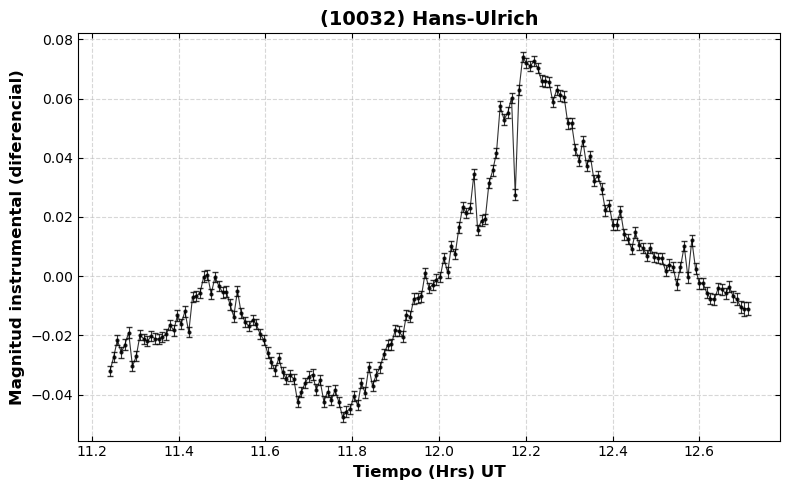


--- DIAGNÓSTICO ---
Rango de horas procesadas: 11.24h a 12.71h


In [11]:
# ==========================================
# 5) CALCULO DE TIEMPO REAL (UT)
# ==========================================

# Convertir Julian Date (JD) a Hora Decimal UT

UTC_hours = [(jd + 0.5) % 1 * 24 for jd in jd_times]
UTC_hours_plot = []
offset_dia = 0
for i, t in enumerate(UTC_hours):
    if i > 0 and t < UTC_hours[i-1] - 12: # Si retrocede más de 12h, cambió el día
        offset_dia += 24
    UTC_hours_plot.append(t + offset_dia)

# ==========================================
# 6) RECENTRAR magnitud
# ==========================================

mag_valida = [m for m in mag_diff if m < 1.0] 
offset = np.nanmean(mag_valida)
mag_diff_centrada = np.array(mag_diff) - offset


plt.figure(figsize=(8, 5))
plt.errorbar(UTC_hours_plot, mag_diff_centrada, yerr=mag_diff_err, 
             fmt='k.-', markersize=4, capsize=2, alpha=0.8, linewidth=0.8)

plt.xlabel('Tiempo (Hrs) UT', fontsize=12, fontweight='bold')
plt.ylabel('Magnitud instrumental (diferencial)', fontsize=12, fontweight='bold')
plt.title('(10032) Hans-Ulrich', fontsize=14, fontweight='bold')
 
plt.grid(True, linestyle='--', alpha=0.5)

plt.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.savefig('curva_final_HansUrish.png', dpi=150)
plt.show()

print("\n--- DIAGNÓSTICO ---")
print(f"Rango de horas procesadas: {min(UTC_hours_plot):.2f}h a {max(UTC_hours_plot):.2f}h")


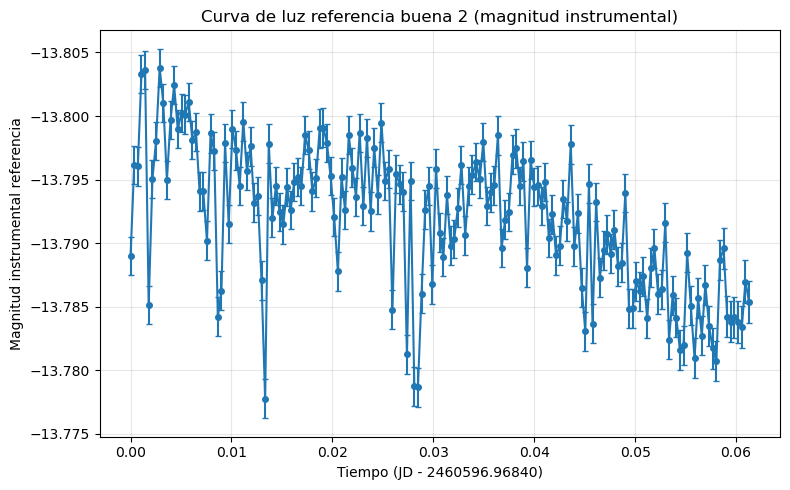

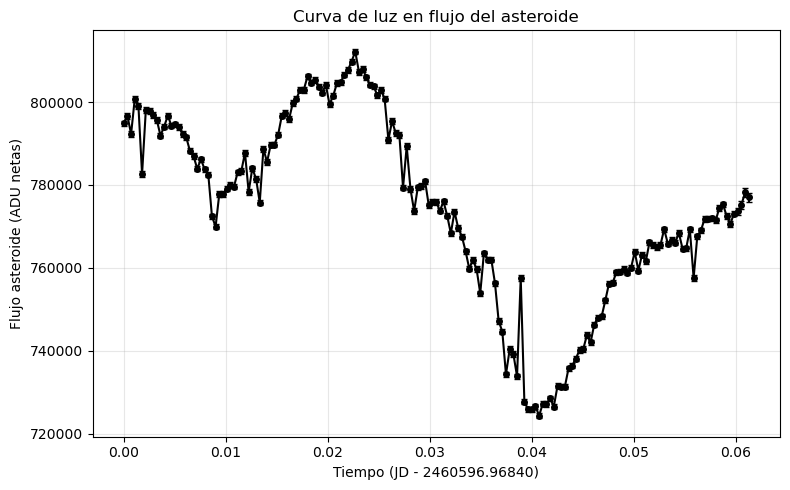

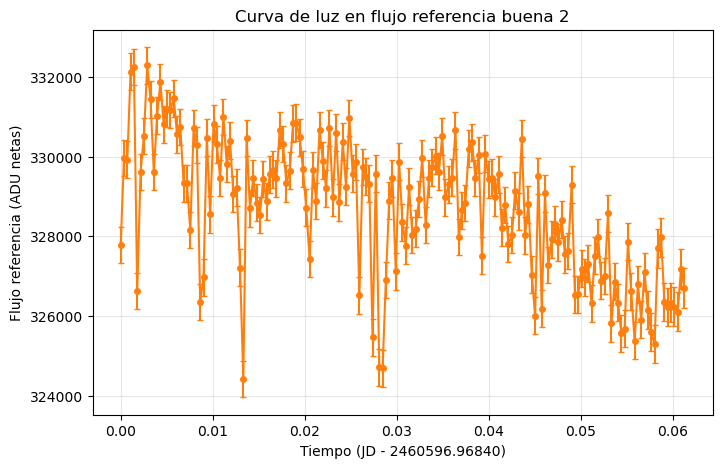

In [13]:
# ==========================================
# 6) GRÁFICAS
# ==========================================

# 6.3 Magnitudes instrumentales de referencias buenas
for k, j in enumerate(refs_buenas_idx):
    m_ref_j = m_refs[:, j]
    dm_ref_j = dm_refs[:, j]

    plt.figure(figsize=(8, 5))
    plt.errorbar(t_rel, m_ref_j, yerr=dm_ref_j,
                 fmt="o-", ms=4, capsize=2, color="C0")
    plt.gca().invert_yaxis()
    plt.xlabel(f"Tiempo (JD - {t0:.5f})")
    plt.ylabel("Magnitud instrumental referencia")
    plt.title(f"Curva de luz referencia buena {j+1} (magnitud instrumental)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6.4 Flujo del asteroide en ADU
plt.figure(figsize=(8, 5))
plt.errorbar(t_rel, asteroid_fluxes, yerr=asteroid_flux_errs,
             fmt="o-", ms=4, capsize=2, color="k")
plt.xlabel(f"Tiempo (JD - {t0:.5f})")
plt.ylabel("Flujo asteroide (ADU netas)")
plt.title("Curva de luz en flujo del asteroide")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6.5 Flujo de referencias buenas en ADU (una figura por estrella)
for k, j in enumerate(refs_buenas_idx):
    F_ref_j = ref_fluxes_all[:, j]
    dF_ref_j = ref_flux_errs_all[:, j]

    plt.figure(figsize=(8, 5))
    plt.errorbar(t_rel, F_ref_j, yerr=dF_ref_j,
                 fmt="o-", ms=4, capsize=2, color="C1")
    plt.xlabel(f"Tiempo (JD - {t0:.5f})")
    plt.ylabel("Flujo referencia (ADU netas)")
    plt.title(f"Curva de luz en flujo referencia buena {j+1}")
    plt.grid(alpha=0.3)
    #plt.tight_layout()
    plt.show()


In [15]:
err_floor = 1e-3
err = np.array(mag_diff_err, dtype=float)
err = np.where(err < err_floor, err_floor, err)

valid = np.isfinite(mag_diff) & np.isfinite(err)

# Sigma clipping sobre la magnitud diferencial
clipped = sigma_clip(
    mag_diff[valid],
    sigma=3,
    maxiters=None,  
    masked=True
)

mask_good = np.zeros_like(mag_diff, dtype=bool)
mask_good[valid] = ~clipped.mask

# índices eliminados
idx_removed = np.where(~mask_good)[0]

mag_diff_clean = mag_diff.copy()
mag_diff_clean[~mask_good] = np.nan

mag_diff_err_clean = mag_diff_err.copy()
mag_diff_err_clean[~mask_good] = np.nan

jd_clean = np.array(jd_times, dtype=float)
jd_clean[~mask_good] = np.nan

print(f"Puntos eliminados: {len(idx_removed)} / {len(mag_diff)}")
print("JD eliminados:", np.round(np.array(jd_times)[idx_removed], 6))

Puntos eliminados: 0 / 171
JD eliminados: []


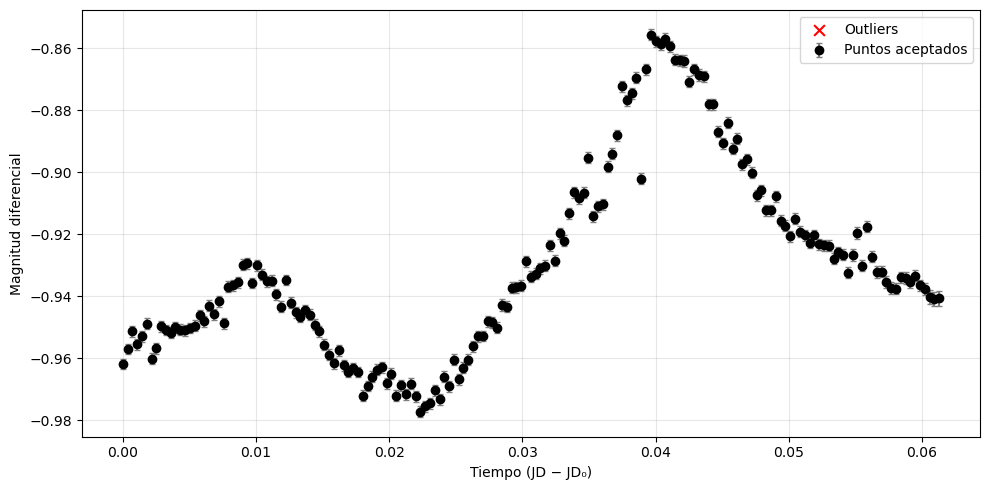

In [17]:
plt.figure(figsize=(10, 5))

# puntos buenos
plt.errorbar(
    t_rel[mask_good],
    mag_diff_clean[mask_good],
    yerr=mag_diff_err_clean[mask_good],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=2,
    label='Puntos aceptados'
)

# outliers
plt.scatter(
    t_rel[~mask_good],
    mag_diff[~mask_good],
    color='red',
    s=60,
    marker='x',
    label='Outliers'
)

plt.xlabel("Tiempo (JD − JD₀)")
plt.ylabel("Magnitud diferencial")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


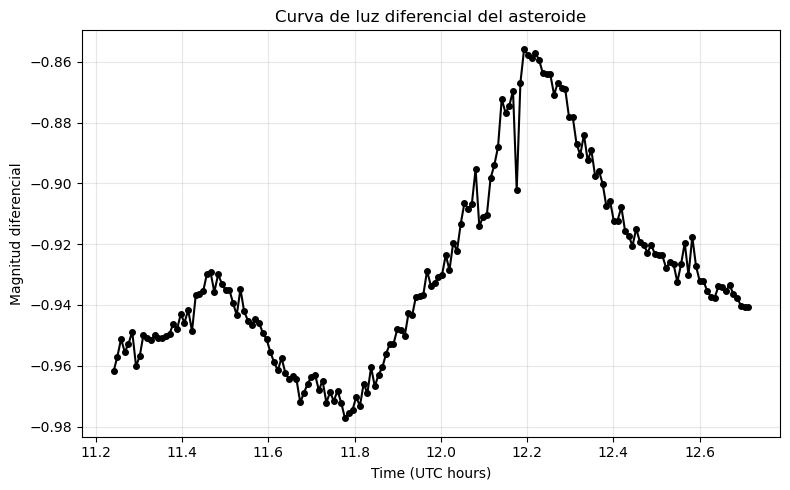

In [19]:
# ==========================================
# 6) Curva de luz en horas UTC 
# ==========================================

UTC_hours = (jd_clean + 0.5) % 1 * 24

# máscara final para graficar (descarta NaN)
mask_plot = np.isfinite(UTC_hours) & np.isfinite(mag_diff_clean)

UTC_hours_valid = UTC_hours[mask_plot]
mag_plot = mag_diff_clean[mask_plot]

# --- 6.2 Corrección de cruce de medianoche ---
UTC_hours_clean = []
offset_dia = 0

for i, t in enumerate(UTC_hours_valid):
    if i > 0 and t < UTC_hours_valid[i-1] - 12:
        offset_dia += 24
    UTC_hours_clean.append(t + offset_dia)

UTC_hours_clean = np.array(UTC_hours_clean)

# --- 6.3 Gráfica ---
plt.figure(figsize=(8, 5))
plt.plot(UTC_hours_clean, mag_plot, "o-", color="k", ms=4)
#plt.gca().invert_yaxis()
plt.xlabel("Time (UTC hours)")
plt.ylabel("Magnitud diferencial")
plt.title("Curva de luz diferencial del asteroide")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
resultados = []
for i in range(len(jd_times)):  
    if mask_good[i]:            
        resultados.append({
            "JD": jd_times[i],
            "mag_diff": mag_diff[i],
            "mag_diff_err": mag_diff_err[i]
        })

df = pd.DataFrame(resultados)


txt_name = os.path.join(folder_path, "fotometria_asteroide_FINAL.txt")
df.to_csv(txt_name, index=False, sep="\t")

print(f"\n✅ Fotometría guardada en:\n - {txt_name}")


✅ Fotometría guardada en:
 - C:/Users/HP/Desktop/Maestria/TESIS/20241013_66146\fotometria_asteroide_FINAL.txt
